<a href="https://colab.research.google.com/github/QuanPhan78/thuchanhdeeplearning/blob/main/Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước x_train: (60000, 784)
Kích thước x_test: (10000, 784)
Đang huấn luyện mô hình...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.0092 - loss: 0.2738 - val_accuracy: 0.0086 - val_loss: 0.1868
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0103 - loss: 0.1692 - val_accuracy: 0.0114 - val_loss: 0.1525
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0109 - loss: 0.1435 - val_accuracy: 0.0111 - val_loss: 0.1330
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0108 - loss: 0.1280 - val_accuracy: 0.0122 - val_loss: 0.1208
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.0116 - loss: 0.1180 - val_accuracy: 0.0107 - val_loss: 0.1127
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0114 - loss: 0.1110 - val_accuracy: 0.0108 - val_loss: 0.1071
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0118 - loss: 0.1

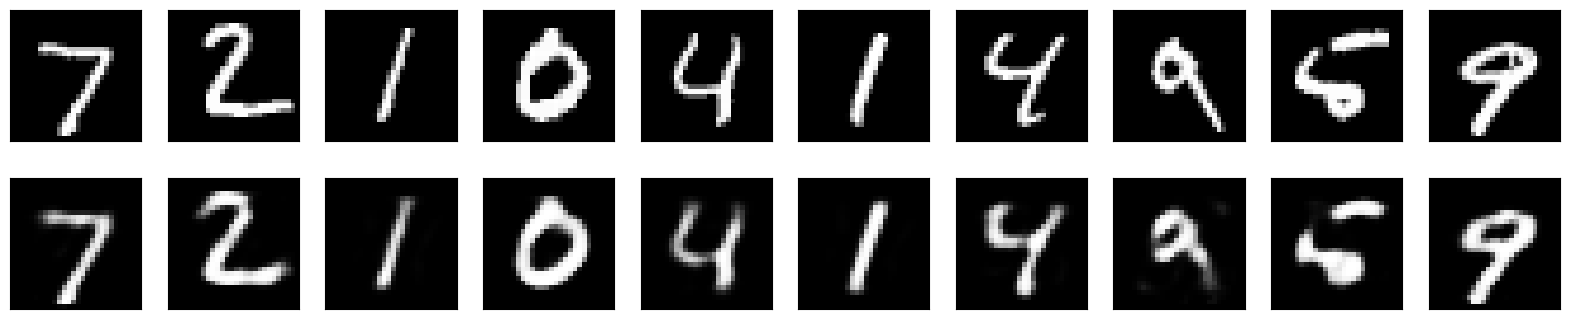

In [ ]:
# 1. Nạp thư viện
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

# 2. Nạp và chuẩn bị dataset
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("Kích thước x_train:", x_train.shape)
print("Kích thước x_test:", x_test.shape)

# 3. Xây dựng mô hình Autoencoder cơ bản
encoding_dim = 32  # Kích thước không gian ẩn (tỷ lệ nén ~24.5)
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Khởi tạo mô hình
autoencoder = keras.Model(input_img, decoded)
encoder = keras.Model(input_img, encoded)

encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

# 4. Huấn luyện mô hình
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Đang huấn luyện mô hình...")
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

# 5. Dự báo và trực quan hóa kết quả
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

n = 10  # Số lượng ảnh muốn hiển thị
plt.figure(figsize=(20, 4))
for i in range(n):
    # Hiển thị ảnh gốc (Original)
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Hiển thị ảnh sau khi khôi phục (Reconstructed)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show() # [cite: 100]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Đang huấn luyện mô hình RNN ---
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0529
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0449
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0384
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0329
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0280
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0240
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0210
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0186 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0169
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0157
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0147
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0142
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0136
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0133
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.01

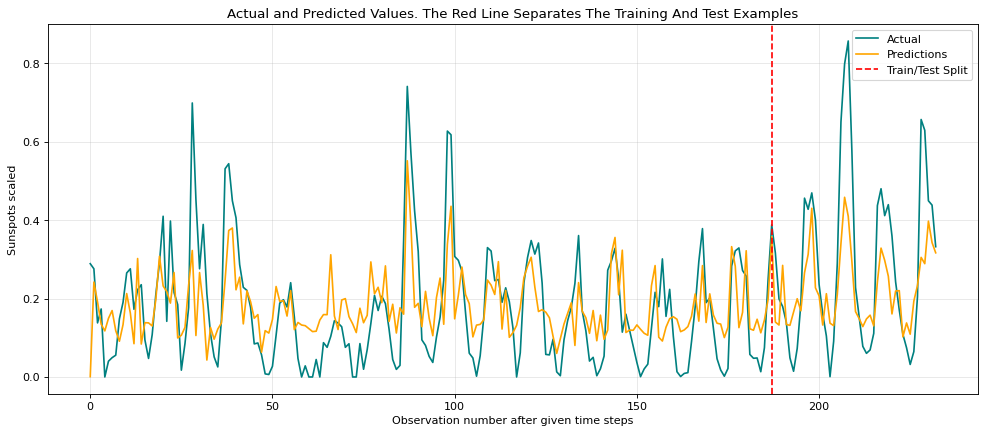

In [ ]:
# ==========================================
# 1. NẠP THƯ VIỆN & ĐỊNH NGHĨA HÀM KHỞI TẠO RNN
# ==========================================
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Hàm tạo mô hình RNN từ mục 2.2 của tài liệu
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# ==========================================
# 2. PHẦN 3.1: ĐỌC VÀ CHUẨN HÓA DỮ LIỆU
# ==========================================
def get_train_test(url, split_percent=0.8):
    # Đọc cột thứ 2 (Sunspots) từ file CSV
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))

    # Chuẩn hóa dữ liệu về khoảng (0, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    # Chia dữ liệu thành tập Train và tập Test
    n = len(data)
    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]

    return train_data, test_data, data

# Đường dẫn URL bộ dữ liệu Sunspots từ tài liệu
sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

# ==========================================
# 3. PHẦN 3.2: CHUẨN BỊ DỮ LIỆU CHO RNN (CỬA SỔ TRƯỢT)
# ==========================================
def get_XY(dat, time_steps):
    # Chỉ số các phần tử mục tiêu Y
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]

    # Chuẩn bị ma trận đầu vào X
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))

    return X, Y

# Sử dụng 12 time_steps tương ứng với 12 tháng để dự báo
time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

# ==========================================
# 4. PHẦN 3.3: KHỞI TẠO MÔ HÌNH VÀ HUẤN LUYỆN
# ==========================================
# Cấu hình mạng: 3 hidden units, 1 đầu ra, hàm kích hoạt tanh
model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps, 1), activation=['tanh', 'tanh'])

print("--- Đang huấn luyện mô hình RNN ---")
# Huấn luyện mô hình với 20 epochs
model.fit(trainX, trainY, epochs=20, verbose=1)

# ==========================================
# 5. PHẦN 3.4: ĐÁNH GIÁ ĐỘ LỖI (RMSE)
# ==========================================
def print_error(trainY, testY, train_predict, test_predict):
    # Tính toán sai số RMSE
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))

    # In kết quả sai số ra màn hình
    print('\n--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ---')
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# Thực hiện dự báo trên cả tập train và tập test
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Gọi hàm tính lỗi
print_error(trainY, testY, train_predict, test_predict)

# ==========================================
# 6. PHẦN 3.5: TRỰC QUAN HÓA KẾT QUẢ ĐỒ THỊ
# ==========================================
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    # Vẽ đồ thị đối chiếu giữa Thực tế (Actual) và Dự đoán (Predictions)
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual', color='teal')
    plt.plot(range(rows), predictions, label='Predictions', color='orange')

    # Đường thẳng màu đỏ ngăn cách giữa dữ liệu Train và dữ liệu Test
    plt.axvline(x=len(trainY), color='r', linestyle='--', label='Train/Test Split')

    plt.legend(['Actual', 'Predictions', 'Train/Test Split'])
    plt.xlabel("Observation number after given time steps")
    plt.ylabel('Sunspots scaled')
    plt.title("Actual and Predicted Values. The Red Line Separates The Training And Test Examples")
    plt.grid(True, alpha=0.3)
    plt.show()

# Vẽ đồ thị kết quả
plot_result(trainY, testY, train_predict, test_predict)